In [1]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from datasets import load_dataset
from math_verify import verify,parse
import json

/data/MaoXiaowei/models/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset(
    "parquet",
    data_files={
        "train": "/data/MaoXiaowei/models/fit/dataset/train-00000-of-00001.parquet"
    },
    split="train",
)
tokenizer = AutoTokenizer.from_pretrained(
    "/data/MaoXiaowei/models/model/Qwen/Qwen2___5-1___5B-Instruct/"
)
model = AutoModelForCausalLM.from_pretrained(
    "/data/MaoXiaowei/models/model/Qwen/Qwen2___5-1___5B-Instruct/",
    torch_dtype=torch.bfloat16,
)
device = "cuda:5"
model = model.to(device)
tokenizer.padding_side = "left"

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


In [3]:
res=[]
with open("outputs/amc23_fullkv.jsonl", "r") as f:
    for line in f:
        data = json.loads(line)
        res.append(data)
len(res)

320

In [4]:
res[0]

{'question': 'Cities $A$ and $B$ are $45$ miles apart. Alicia lives in $A$ and Beth lives in $B$. Alicia bikes towards $B$ at 18 miles per hour. Leaving at the same time, Beth bikes toward $A$ at 12 miles per hour. How many miles from City $A$ will they be when they meet?',
 'answer': '27',
 'prompt': '<｜begin▁of▁sentence｜>Please reason step by step, and put your final answer within \\boxed{}.<｜User｜>Cities $A$ and $B$ are $45$ miles apart. Alicia lives in $A$ and Beth lives in $B$. Alicia bikes towards $B$ at 18 miles per hour. Leaving at the same time, Beth bikes toward $A$ at 12 miles per hour. How many miles from City $A$ will they be when they meet?<｜Assistant｜><think>\n',
 'index': 0,
 'output': "Okay, so I have this problem here about two cities, A and B, which are 45 miles apart. Alicia lives in city A and she's biking towards city B at a speed of 18 miles per hour. At the same time, Beth lives in city B and she's also biking towards city A at a speed of 12 miles per hour. The 

In [5]:
all_seq=[]
for i in range(len(res)):
    all_seq.append(tokenizer(res[i]["prompt"]+res[i]["output"]))

In [6]:
all_seq[0]

{'input_ids': [27, 130957, 7265, 10417, 223, 1055, 10417, 223, 51889, 130957, 29, 5501, 2874, 3019, 553, 3019, 11, 323, 2182, 697, 1590, 4226, 2878, 1124, 79075, 6257, 15757, 130957, 1474, 130957, 29, 76613, 400, 32, 3, 323, 400, 33, 3, 525, 400, 19, 20, 3, 8756, 10747, 13, 78902, 6305, 304, 400, 32, 3, 323, 28003, 6305, 304, 400, 33, 12947, 78902, 30453, 6974, 400, 33, 3, 518, 220, 16, 23, 8756, 817, 6460, 13, 72962, 518, 279, 1852, 882, 11, 28003, 30453, 8841, 400, 32, 3, 518, 220, 16, 17, 8756, 817, 6460, 13, 2585, 1657, 8756, 504, 4311, 400, 32, 3, 686, 807, 387, 979, 807, 3367, 75414, 130957, 71703, 130957, 1784, 26865, 397, 32313, 11, 773, 358, 614, 419, 3491, 1588, 911, 1378, 9720, 11, 362, 323, 425, 11, 892, 525, 220, 19, 20, 8756, 10747, 13, 78902, 6305, 304, 3283, 362, 323, 1340, 594, 66080, 6974, 3283, 425, 518, 264, 4628, 315, 220, 16, 23, 8756, 817, 6460, 13, 2411, 279, 1852, 882, 11, 28003, 6305, 304, 3283, 425, 323, 1340, 594, 1083, 66080, 6974, 3283, 362, 518, 264, 4628

# Group Attention Score

In [7]:
@torch.no_grad()
def get_attn_score(model, input_tensor, window_size=256):
    """
    Get attention scores for a given input tensor.
    Args:
        model: The model to use for attention scoring.
        input_tensor: The input tensor to score.
        window_size: The size of the window to use for attention scoring.
    Returns:
        attn_score: (B, H, W, L) - Attention scores for each token.
    """
    outputs = model(
        input_tensor,
        output_attentions=True,
        output_hidden_states=True,
        return_dict=True,
    )
    attn_score = outputs.attentions[-1][:, :, -window_size:, :-window_size]
    return attn_score

In [8]:
@torch.no_grad()
def cross_salience_score(
    attention_weights,
    num_group=4,
):
    """
    Calculate group attention scores for tokens based on attention weights

    Args:
        attention_weights: (B, H, W, L) - Attention weights between tokens
        num_group: int - Number of groups to split the attention weights into
        epsilon: float - Small constant to avoid log(0)

    Returns:
        cross_salience_score: (B, H, L) - Cross salience score for each token
    """
    assert (
        attention_weights.shape[2] % num_group == 0
    ), f"window size {attention_weights.shape[2]} must be divisible by group {num_group}"

    group_size = attention_weights.shape[2] // num_group

    if num_group > 1:
        # 将循环改为非循环实现
        B, H, W, L = attention_weights.shape
        # 先reshape，将window维度分为(num_group, group_size)
        group_attention_weights = attention_weights.view(B, H, num_group, group_size, L)
        # 对group_size维度求均值，得到(B, H, num_group, L)
        all_score = group_attention_weights.mean(dim=3)
        # all_score = all_score.div_(all_score.max(dim=-1, keepdim=True).values)
        # shape (B, H, G, G, L)
        all_score = all_score.unsqueeze(2) * all_score.unsqueeze(3)
        # mask the diagonal elements
        mask = torch.eye(all_score.shape[2], device=all_score.device).bool()  # (G, G)
        mask = mask.unsqueeze(0).unsqueeze(0).unsqueeze(-1)
        all_score = all_score.masked_fill(mask, 0)
        # shape (B, H, L)
        all_score = all_score.sum(dim=(2, 3))
        all_score = torch.log(1 + all_score)+1e-2*all_score
    else:
        all_score = attention_weights.mean(dim=(2))
    all_score = all_score / all_score.max(dim=-1, keepdim=True).values
    return all_score

`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


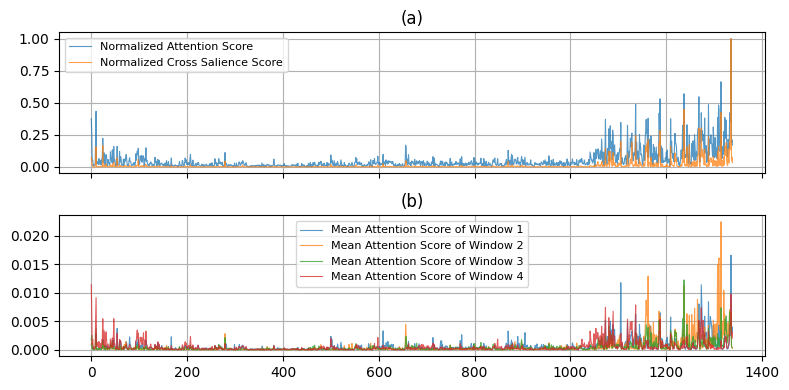

In [ ]:
# Create a figure with two subplots side by side
window_size = 128
seq_id = 0
num_group = 2
input_tensor = torch.tensor(all_seq[seq_id]['input_ids']).unsqueeze(0).to(device)
attn_score = get_attn_score(model, input_tensor, window_size=window_size)

cs_score = cross_salience_score(attn_score, num_group=num_group)
cs_scores = []
num_groups = [1, 2]
for num_group in num_groups:
    cs_score = cross_salience_score(attn_score, num_group=num_group)
    mcs_score = cs_score.mean(dim=(1))
    mcs_score = mcs_score / mcs_score.max(dim=-1, keepdim=True).values
    # mcs_score=torch.log(1+mcs_score)
    cs_scores.append(mcs_score)

fig, axs = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

lable=["Normalized Attention Score","Normalized Cross Salience Score"]
for i, s in enumerate(cs_scores):
    axs[0].plot(
        s.squeeze().cpu().detach().float().numpy(),
        linewidth=0.8,
        label=lable[i],
        alpha=0.75,
    )
axs[0].set_title("(a)")
axs[0].legend(fontsize=8)
axs[0].grid(True)

slice_len = window_size // 4
score_sums = []
for i in range(0, window_size, slice_len):
    score_sum = attn_score[:, :, i : i + slice_len, :]
    score_sum = score_sum.mean(dim=(1, 2))
    score_sums.append(score_sum)

for i, s in enumerate(score_sums):
    axs[1].plot(
        s.squeeze().cpu().detach().float().numpy(),
        linewidth=0.8,
        alpha=0.75,
        label=f"Mean Attention Score of Window {i+1}",
    )
axs[1].set_title("(b)")
axs[1].legend(fontsize=8)
axs[1].grid(True)

plt.tight_layout()
# plt.savefig("cross_salience.pdf",format="pdf")
plt.show()

In [24]:
import gc
window_size = 256
num_group = 2
k = [0.55, 0.65, 0.75, 0.85, 0.95]
all_res = []
for seq_id in tqdm(range(len(all_seq))):
    if len(all_seq[seq_id]['input_ids'])>4000:
        continue
    input_tensor = torch.tensor(all_seq[seq_id]['input_ids']).unsqueeze(0).to(device)
    torch.cuda.empty_cache()
    gc.collect()
    # (B,H,W,L)
    attn_score = get_attn_score(model, input_tensor, window_size=window_size)
    # (B,H,L)
    slice_len = window_size // 4
    score_sums = []
    for i in range(0, window_size, slice_len):
        score_sum = attn_score[:, :, i : i + slice_len, :]
        score_sum = score_sum.mean(dim=(1, 2))
        score_sums.append(score_sum)

    score_sums_np = [s.squeeze().cpu().detach().float().numpy() for s in score_sums]

    res = []
    for top_k in k:
        top_k = int(top_k * score_sums_np[0].shape[0])
        # 以第一个 window 为基准
        win1_topk_indices = np.argsort(score_sums_np[0])[-top_k:]
        # 分别计算后面三个 window 和第一个 window 的top-p重合率
        all_consistency = []
        for w in range(1, 4):
            winw_topk_indices = np.argsort(score_sums_np[w])[-top_k:]
            intersection = np.intersect1d(win1_topk_indices, winw_topk_indices)
            consistency = len(intersection) / top_k
            all_consistency.append(consistency)
        # 计算最后一个窗口被前三个窗口的并集所包含的比率
        win123_topk_indices = np.argsort(
            np.concatenate([score_sums_np[0], score_sums_np[1], score_sums_np[2]])
        )[-top_k * 3 :]
        win123_topk_indices = np.unique(
            np.concatenate(
                [
                    np.argsort(score_sums_np[0])[-top_k:],
                    np.argsort(score_sums_np[1])[-top_k:],
                    np.argsort(score_sums_np[2])[-top_k:],
                ]
            )
        )
        win4_topk_indices = np.argsort(score_sums_np[3])[-top_k:]
        intersection = np.intersect1d(win4_topk_indices, win123_topk_indices)
        win4_in_123_union = len(intersection) / top_k
        all_consistency.append(win4_in_123_union)
        res.append(all_consistency)
    all_res.append(res)

100%|██████████| 320/320 [01:23<00:00,  3.84it/s]


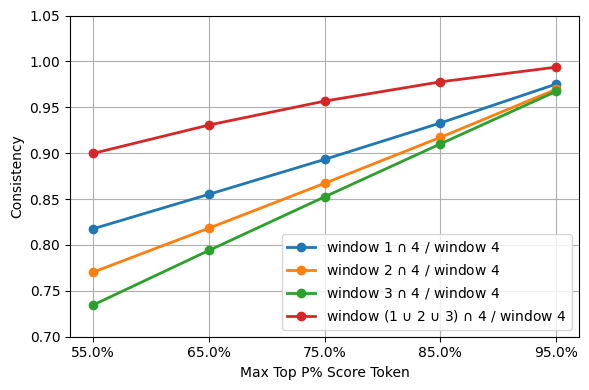

In [25]:
res_np = np.array(all_res)

res_np = res_np.mean(axis=0)
plt.figure(figsize=(6, 4))
x_pos = np.arange(len(k))
res_np = np.array(res_np)

label=["window 1 $\\cap$ 4 / window 4",
       "window 2 $\\cap$ 4 / window 4",
       "window 3 $\\cap$ 4 / window 4",
       "window (1 $\\cup$ 2 $\\cup$ 3) $\\cap$ 4 / window 4",]
for i in range(4):
    plt.plot(
        x_pos,
        res_np[:,i],
        marker="o",
        label=label[i],
        linewidth=2,
    )
plt.xlabel("Max Top P% Score Token")
plt.ylabel("Consistency")
plt.ylim(0.7, 1.05)
plt.grid(True)
plt.xticks(x_pos, [f"{i*100:.1f}%" for i in k])
plt.legend()
plt.tight_layout()
plt.savefig("pdf/window256_consistency.pdf", format="pdf")
plt.show()

In [27]:
min_len=100000
idx=0
for i in range(len(all_seq)):
    if len(all_seq[i]['input_ids'])<min_len:
        min_len=len(all_seq[i]['input_ids'])
        idx=i

min_len,idx


(1117, 4)

In [40]:
# 颜色定义：蓝色（窗口1关注窗口4没关注），橙色（窗口2关注窗口4没关注），绿色（窗口3关注窗口4没关注），红色（窗口4关注且1/2/3关注过），紫色（窗口4单独关注）
colors = [
    "#1f77b4",  # 蓝色，窗口1关注窗口4没关注
    "#ff7f0e",  # 橙色，窗口2关注窗口4没关注
    "#2ca02c",  # 绿色，窗口3关注窗口4没关注
    "#d62728",  # 红色，窗口4关注且1/2/3关注过
    "#9467bd",  # 紫色，窗口4单独关注
]
latext_strs = []
tex_str = "\\begin{figure}[!thp]\n\\begin{tcolorbox}[colframe=black!80,colback=gray!3,coltitle=black,colbacktitle=gray!40,fonttitle=\\bfseries,width=\\textwidth,boxrule=0.5mm,title=Incorrect Example 2,fontupper=\\scriptsize]\\setlength{\\baselineskip}{4pt}\n"
generated_tokens = all_seq[idx]['input_ids']
window_size = 256

input_tensor = torch.tensor(all_seq[idx]['input_ids']).unsqueeze(0).to(device)
attn_score = get_attn_score(model, input_tensor, window_size=window_size)
slice_len = window_size // 4
score_sums = []
for i in range(0, window_size, slice_len):
    score_sum = attn_score[:, :, i : i + slice_len, :]
    score_sum = score_sum.mean(dim=(1, 2))
    score_sums.append(score_sum)

# 根据4个窗口的得分确定不同颜色的集合
# 这里假设score_sums为长度4的列表，每个元素为当前窗口的得分（tensor, shape: [1, seq_len]）
# 计算每个窗口的top-p分数token集合（以top 10%为例，可根据需要调整）

top_p = 0.9  # 取前10%分数的token
win_top_p = []
for i in range(4):
    scores = score_sums[i].squeeze(0).cpu().float().numpy()
    threshold = np.percentile(scores, 100 * (1 - top_p))
    win_top_p.append(scores >= threshold)

# 得到每个token在4个窗口是否为top-p
win1_top_p = win_top_p[0]
win2_top_p = win_top_p[1]
win3_top_p = win_top_p[2]
win4_top_p = win_top_p[3]


for j, token_id in enumerate(generated_tokens):
    token = tokenizer.decode(token_id)
    if "｜" in token :
        token = token.replace("｜", "|")
    elif "▁" in token:
        token = token.replace("▁", "")

    token = (token.replace("\\", "\\textbackslash")
            .replace("\n", "\\\\")
            .replace("_", "\\_")
            .replace("%", "\\%")
            .replace("$", "\\$")
            .replace("&", "\\&") 
            .replace("{", "\\{")
            .replace("}", "\\}")
            .replace("~", "\\~")
            .replace("^", "\\^")
            .replace("|", "$|$"))
    token = token.replace("\\textbackslash", "{\\textbackslash}")

    if j>=len(generated_tokens)-window_size-1:
        color_idx = None
    elif win1_top_p[j] and not win4_top_p[j]:
        color_idx = 0
    # 橙色：窗口2关注且窗口4没关注
    elif win2_top_p[j] and not win4_top_p[j]:
        color_idx = 1
    # 绿色：窗口3关注且窗口4没关注
    elif win3_top_p[j] and not win4_top_p[j]:
        color_idx = 2
    # 红色：窗口4关注且窗口1/2/3有一个关注过
    elif win4_top_p[j] and (win1_top_p[j] or win2_top_p[j] or win3_top_p[j]):
        color_idx = 3
    # 紫色：窗口4关注且窗口1/2/3都没关注
    elif win4_top_p[j] and not (win1_top_p[j] or win2_top_p[j] or win3_top_p[j]):
        color_idx = 4
    else:
        # 其他情况不着色，默认黑色
        color_idx = None

    if color_idx is not None:
        hex_color = colors[color_idx].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16)/255 for i in (0, 2, 4))
        color_str = f"{rgb[0]:.3f},{rgb[1]:.3f},{rgb[2]:.3f}"
        tex_str += f"\\textcolor[rgb]{{{color_str}}}{{\\texttt{{{token}}}}}\\hspace{{0pt}}"
    else:
        tex_str += f"\\texttt{{{token}}}\\hspace{{0pt}}"

tex_str += "\n\\end{tcolorbox}\n\\end{figure}"
latext_strs.append(tex_str)
print(latext_strs[0])

\begin{figure}[!thp]
\begin{tcolorbox}[colframe=black!80,colback=gray!3,coltitle=black,colbacktitle=gray!40,fonttitle=\bfseries,width=\textwidth,boxrule=0.5mm,title=Incorrect Example 2,fontupper=\scriptsize]\setlength{\baselineskip}{4pt}
\textcolor[rgb]{0.839,0.153,0.157}{\texttt{<}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{$|$}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{begin}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{�}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{�}}\hspace{0pt}\textcolor[rgb]{0.580,0.404,0.741}{\texttt{of}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{�}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{�}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{sentence}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{$|$}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{>}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{Please}}\hspace{0pt}\textcolor[rgb]{0.839,0.153,0.157}{\texttt{ r

In [36]:
print(tokenizer.decode(all_seq[idx]['input_ids']))

<｜begin▁of▁sentence｜>Please reason step by step, and put your final answer within \boxed{}.<｜User｜>Cities $A$ and $B$ are $45$ miles apart. Alicia lives in $A$ and Beth lives in $B$. Alicia bikes towards $B$ at 18 miles per hour. Leaving at the same time, Beth bikes toward $A$ at 12 miles per hour. How many miles from City $A$ will they be when they meet?<｜Assistant｜><think>
Okay, so I have this problem where cities A and B are 45 miles apart. Alicia lives in city A and she's biking towards city B at a speed of 18 miles per hour. At the same time, Beth lives in city B and she's biking towards city A at 12 miles per hour. The question is asking how many miles from city A they will meet.

Hmm, let me think about how to approach this. It seems like a relative speed problem where two objects are moving towards each other. So, maybe I can use the concept of combined speed here.

First, let me note down the given information:

- Distance between A and B: 45 miles
- Alicia's speed: 18 mph
- B

In [32]:
len(win1_top_p)

861